# Group 6 - Data Analytics Project Activity: From Raw Data to Interactive Dashboard

🎯 **Objective**

In this activity, you will take a real-world dataset, clean and prepare it (data wrangling), perform exploratory data analysis (EDA), and finally build an interactive dashboard using Python. This mirrors a real job workflow used by Data Analysts and Business Intelligence professionals.

## 🧩 Step 1: Dataset Selection (Real-World Data)

For this project, we have decided to use a Retail Sales Dataset from Kaggle. Here is the link to the source:

https://www.kaggle.com/datasets/mohammadtalib786/retail-sales-dataset

In [1]:
import kagglehub

# Download latest version of kaggle dataset
path = kagglehub.dataset_download("mohammadtalib786/retail-sales-dataset")

print("Path to dataset files:", path)

100%|██████████| 11.2k/11.2k [00:00<00:00, 14.7MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/mohammadtalib786/retail-sales-dataset/versions/1


To check the requirements, in the code block below we can confirm that we have met every requirements:
*   ✅ At least 100+ rows - 1000 entries
*   ✅ At least 4 columns - 9 columns
*   ✅ A time-based column (date/month/year) preferred - Date column

In [2]:
import pandas as pd

# load kaggle path to pandas dataframe
df_main = pd.read_csv(path + '/retail_sales_dataset.csv')
df_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


## 🧹 Step 2: Data Wrangling (Cleaning & Preparation)

1. Load Dataset

In [3]:
# We have loaded the dataset from step #1 and here is the preview
df_main

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150


2. Handle Missing Value

In [4]:
# If we look at all the sum of null or missing values, we can say that we do not have any missing values
df_main.isnull().sum()

,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


3. Fix Data Types

In [5]:
# To take a peek of the current data types
df_main.dtypes

,0
Transaction ID,int64
Date,object
Customer ID,object
Gender,object
Age,int64
Product Category,object
Quantity,int64
Price per Unit,int64
Total Amount,int64


In [6]:
# Here we want to change Date from 'object' to 'datetime'
df_main['Date'] = pd.to_datetime(df_main['Date'])
# Now if we look back at the types, it is now changed to 'datetime'
df_main.dtypes

,0
Transaction ID,int64
Date,datetime64[ns]
Customer ID,object
Gender,object
Age,int64
Product Category,object
Quantity,int64
Price per Unit,int64
Total Amount,int64


4. Remove Duplicates (if any)

In [7]:
# If we check if there are any duplicates in our dataframe, we have 0 duplicates
df_main.duplicated().sum()

np.int64(0)

5. Create new columns (feature engineering). Here we will try 2 things:
* Give new columns for the Date's Year and Month
* Binning the Age to different Age Groups

In [8]:
# Here is how we create new columns named 'Year' and 'Month' based on the 'Date' column
df_main['Year'] = df_main['Date'].dt.year
df_main['Month'] = df_main['Date'].dt.month

# if we look at the data types again, we can see two new columns
df_main.dtypes

,0
Transaction ID,int64
Date,datetime64[ns]
Customer ID,object
Gender,object
Age,int64
Product Category,object
Quantity,int64
Price per Unit,int64
Total Amount,int64
Year,int32


In [9]:
# Also to peek at the first 5 rows and see Year and Month are correctly supplied
df_main.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Year,Month
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,2023,11
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2023,2
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,2023,1
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,2023,5
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,2023,5


In [10]:
# For the 2nd objective, we will create bins for the age group based on decades (e.g. 0-9, 10-19, 20-29, etc.)
age_bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 969]
age_labels = ['00s', '10s', '20s', '30s', '40s', '50s', '60s', '70s', '80s', '90+']
df_main['Age Group'] = pd.cut(df_main['Age'], bins=age_bins, labels=age_labels, right=False)

# let us see the new bin column
df_main.head(10)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Year,Month,Age Group
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,2023,11,30s
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2023,2,20s
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,2023,1,50s
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,2023,5,30s
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,2023,5,30s
5,6,2023-04-25,CUST006,Female,45,Beauty,1,30,30,2023,4,40s
6,7,2023-03-13,CUST007,Male,46,Clothing,2,25,50,2023,3,40s
7,8,2023-02-22,CUST008,Male,30,Electronics,4,25,100,2023,2,30s
8,9,2023-12-13,CUST009,Male,63,Electronics,2,300,600,2023,12,60s
9,10,2023-10-07,CUST010,Female,52,Clothing,4,50,200,2023,10,50s


In [11]:
# we can furthur confirm our binning with the following code, we can see the min and max values for each age group
df_main.groupby('Age Group')['Age'].agg(['min', 'max']).reset_index()

/tmp/ipykernel_2605/1878145145.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_main.groupby('Age Group')['Age'].agg(['min', 'max']).reset_index()


,Age Group,min,max
0,00s,NaN,NaN
1,10s,18.0,19.0
2,20s,20.0,29.0
3,30s,30.0,39.0
4,40s,40.0,49.0
5,50s,50.0,59.0
6,60s,60.0,64.0
7,70s,NaN,NaN
8,80s,NaN,NaN
9,90+,NaN,NaN


## 📊 Step 3: Exploratory Data Analysis (EDA)

1. Basic Statistics

In [12]:
# to see basic statistics of each column
df_main.describe(include='all')

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Year,Month,Age Group
count,1000.000000,1000,1000,1000,1000.00000,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000
unique,NaN,NaN,1000,2,NaN,3,NaN,NaN,NaN,NaN,NaN,6
top,NaN,NaN,CUST1000,Female,NaN,Clothing,NaN,NaN,NaN,NaN,NaN,40s
freq,NaN,NaN,1,510,NaN,351,NaN,NaN,NaN,NaN,NaN,222
mean,500.500000,2023-07-03 00:25:55.200000256,NaN,NaN,41.39200,NaN,2.514000,179.890000,456.000000,2023.002000,6.549000,NaN
min,1.000000,2023-01-01 00:00:00,NaN,NaN,18.00000,NaN,1.000000,25.000000,25.000000,2023.000000,1.000000,NaN
25%,250.750000,2023-04-08 00:00:00,NaN,NaN,29.00000,NaN,1.000000,30.000000,60.000000,2023.000000,4.000000,NaN
50%,500.500000,2023-06-29 12:00:00,NaN,NaN,42.00000,NaN,3.000000,50.000000,135.000000,2023.000000,6.000000,NaN
75%,750.250000,2023-10-04 00:00:00,NaN,NaN,53.00000,NaN,4.000000,300.000000,900.000000,2023.000000,10.000000,NaN
max,1000.000000,2024-01-01 00:00:00,NaN,NaN,64.00000,NaN,4.000000,500.000000,2000.000000,2024.000000,12.000000,NaN


2. Group Analysis adjusted based on dataset:
* Sales by Product Category
* Profit by Age Group
* Monthly Trends

In [13]:
df_main.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount',
       'Year', 'Month', 'Age Group'],
      dtype='object')

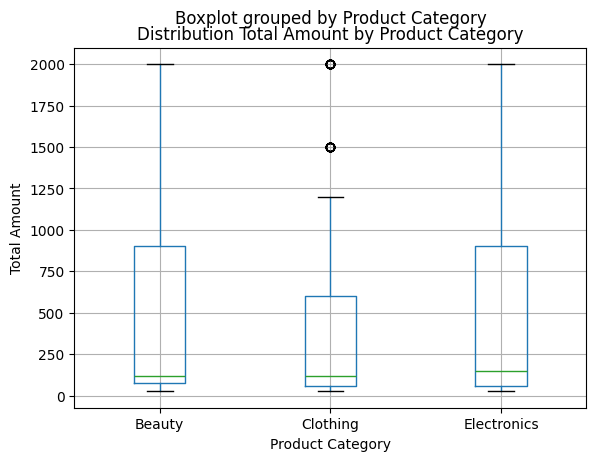

In [14]:
#Mounika working on Box Plot
import matplotlib.pyplot as plt
import seaborn as sns
df_main.boxplot(column=['Total Amount'], by='Product Category')
plt.title('Distribution Total Amount by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Amount')
plt.show()

3. Visualization (Minimum of 4 Required)

* Bar Chart
* Line Chart
* Pie Chart
* Box Plot

🧠 Questions to Answer adjusted based on dataset:
* What 'Product Category' generates the highest revenue?
* What 'Month' shows when people spend the most?
* Are there any unusual patterns or outliers?
* Which 'Age Group' spends the most?

## 📈 Step 4: Build Interactive Dashboard (Final Project)

📌 Task Create an interactive dashboard using: Dash (Plotly)

To help us in using Dash (Plotly) in Google Colab, here is a link that may prove as a guide:

https://colab.research.google.com/github/rapidsai/plotly-dash-rapids-census-demo/blob/main/plotly_demo/colab_plotly_rapids_app.ipynb

📊 Dashboard Must Include:

1. Filters

* Year dropdown OR category filter

2. Visualizations (minimum 4–5):

* Bar chart (Category vs Sales)
* Line chart (Time trend)
* Pie chart (Distribution)
* Box plot (Spread)
* Optional: Sunburst / Heatmap

🧠 Dashboard Features:

* Interactive filtering
* Dynamic charts
* Clean layout
* Clear titles and labels

💡 Bonus (Optional but recommended):

* KPI cards (Total Sales, Profit, Avg Value)
* YoY comparison
* Export dataset feature

In [15]:
# Karen, (Task: Setup, Dashboard Filters)

*Karen* (Task: **Setup, Dashboard Filters + Sample Graph - Histogram**)

In [16]:
!pip install dash dash_bootstrap_components jupyter-dash dash-html-components dash-core-components dash-daq dash-bootstrap-components "datashader>=0.15" pyproj bokeh

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 67.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 676.0/676.0 kB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 80.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 86.1 MB/s eta 0:00:00


In [17]:
!pip install dash pandas plotly kagglehub

In [18]:
import os
import glob
import pandas as pd
import dash
from dash import dcc, html
from dash.dependencies import Input, Output
import plotly.express as px
import kagglehub

# Data Preprocessing
# Convert Date column to datetime and extract the Year
df_main['Date'] = pd.to_datetime(df_main['Date'])
df_main['Year'] = df_main['Date'].dt.year
df_main.columns = df_main.columns.str.strip()  # Clean up any accidental whitespaces

# Initialize the Dash App
app = dash.Dash(__name__)

# App Layout
app.layout = html.Div([
    html.H1("Retail Sales Dashboard", style={'textAlign': 'center', 'fontFamily': 'Arial', 'color': '#2c3e50'}),

    # Filter Panel
    html.Div([
        # Product Category Filter
        html.Div([
            html.Label("Select Product Category:", style={'fontWeight': 'bold'}),
            dcc.Dropdown(
                id='category-dropdown',
                options=[{'label': cat, 'value': cat} for cat in df_main['Product Category'].unique()],
                value=df_main['Product Category'].unique().tolist(),  # Defaults to selecting all
                multi=True
            )
        ], style={'width': '48%', 'display': 'inline-block'}),

        # Year Filter
        html.Div([
            html.Label("Select Year:", style={'fontWeight': 'bold'}),
            dcc.Dropdown(
                id='year-dropdown',
                options=[{'label': str(year), 'value': year} for year in sorted(df_main['Year'].unique())],
                value=sorted(df_main['Year'].unique()),  # Defaults to selecting all
                multi=True
            )
        ], style={'width': '48%', 'display': 'inline-block'})
    ], style={'display': 'flex', 'justifyContent': 'space-between', 'marginBottom': '30px', 'padding': '10px', 'backgroundColor': '#f8f9fa', 'borderRadius': '5px'}),

    # Graph Container
    html.Div([
        dcc.Graph(id='sales-histogram')
    ])
], style={'padding': '20px', 'fontFamily': 'Arial'})

# Callback to link filters with the histogram
@app.callback(
    Output('sales-histogram', 'figure'),
    [Input('category-dropdown', 'value'),
     Input('year-dropdown', 'value')]
)

def update_graph(selected_categories, selected_years):
    # Fallback to prevent app crashing if a user clears all selections
    if not selected_categories or not selected_years:
        fig = px.histogram(title="Please select at least one Product Category and Year.")
        fig.update_layout(plot_bgcolor='white', paper_bgcolor='white')
        return fig

    # Filter the dataset dynamically
    filtered_df = df_main[
        (df_main['Product Category'].isin(selected_categories)) &
        (df_main['Year'].isin(selected_years))
    ]

    # sample graph: a histogram showing the sales distribution
    fig = px.histogram(
        filtered_df,
        x='Total Amount',
        nbins=25,
        title='Distribution of Sales (Total Amount)',
        labels={'Total Amount': 'Transaction Value ($)', 'count': 'Transaction Count'},
        color_discrete_sequence=['#3498db']
    )

    # Style formatting for a cleaner visual look
    fig.update_layout(
        bargap=0.08,
        plot_bgcolor='white',
        paper_bgcolor='white',
        xaxis=dict(showgrid=True, gridcolor='#e9ecef'),
        yaxis=dict(showgrid=True, gridcolor='#e9ecef'),
        title_font=dict(size=18, family='Arial')
    )

    return fig



HeatMap

In [19]:
import plotly.express as px

# Aggregate sales data
sunburst_data = (
    df_main.groupby(['Product Category', 'Gender', 'Age Group'])['Total Amount']
    .sum()
    .reset_index()
)

# Create Sunburst Chart
fig = px.sunburst(
    sunburst_data,
    path=['Product Category', 'Gender', 'Age Group'],
    values='Total Amount',
    title='Retail Sales Distribution by Category, Gender, and Age Group'
)

fig.update_layout(
    width=900,
    height=700
)

fig.show()

/tmp/ipykernel_2605/2926184598.py:5: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/usr/local/lib/python3.12/dist-packages/plotly/express/_core.py:1727: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



### Exposing the Dash App with ngrok

Since `http://127.0.0.1:8050/` is a local address within the Colab environment, it's not directly accessible from your browser. To access the Dash dashboard, we need to expose the Colab port to the internet using `ngrok`.

**Steps to set up ngrok:**
1. Go to [ngrok.com](https://ngrok.com) and create a free account.
2. After logging in, go to the "Your Authtoken" section on the dashboard.
3. Copy your authtoken.
4. In your Google Colab notebook, click the "🔑" icon on the left sidebar (Secrets).
5. Add a new secret with the name `NGROK_AUTH_TOKEN` and paste your authtoken as the value.

In [20]:
# Install pyngrok if not already installed
!pip install pyngrok -q


In [22]:
import os
from pyngrok import ngrok, conf
from google.colab import userdata

# Terminate any existing ngrok tunnels
ngrok.kill()

# Get ngrok authentication token from Colab secrets
NGROK_AUTH_TOKEN = userdata.get('NGROK_AUTH_TOKEN')

# Check if the token is available
if NGROK_AUTH_TOKEN:
    # Set ngrok authtoken
    conf.get_default().auth_token = NGROK_AUTH_TOKEN
    print("ngrok authtoken set.")

    # Open a tunnel to port 8050, where the Dash app is running
    # The Dash app is running on port 8050, as specified in `app.run(jupyter_mode="inline", port=8050)`
    public_url = ngrok.connect(8050)

    print(f"Dash app is publicly available at: {public_url}")
else:
    print("NGROK_AUTH_TOKEN not found. Please add it to Colab secrets as instructed.")


ngrok authtoken set.
Dash app is publicly available at: NgrokTunnel: "https://balsamic-numbness-vanish.ngrok-free.dev" -> "http://localhost:8050"


In [ ]:
if __name__ == '__main__':
    # Force Dash to listen on all interfaces so ngrok can find it
    app.run(host='0.0.0.0', port=8050)

Dash is running on http://0.0.0.0:8050/



INFO:dash.dash:Dash is running on http://0.0.0.0:8050/



 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:8050
 * Running on http://172.28.0.12:8050
INFO:werkzeug:Press CTRL+C to quit


## Final Submission Requirements

📦 Final Submission Requirements

You must submit:
1. Python notebook or script
* Data cleaning + EDA + dashboard code

2. Dataset used
* Original dataset file or link

3. Short report (1–2 pages) Include:
* Dataset chosen
* Key insights
* Challenges faced
* What you learned